# 03: Computer Vision Pipeline Demo
Notebook này chạy toàn bộ Pipeline nhận diện bãi đỗ xe trên các khung hình video, sử dụng logic từ `backend/core_cv/pipeline.py`.

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import json

# Tách biệt hoàn toàn khỏi backend

def apply_preprocessing(image):
    # Kỹ thuật Chương 2: Tiền xử lý ảnh
    resized = cv2.resize(image, (64, 128))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    equalized = clahe.apply(gray)
    blurred = cv2.GaussianBlur(equalized, (3, 3), 0)
    return blurred


def get_hog_descriptor():
    # Kỹ thuật Chương 3: Trích xuất đặc trưng hình học
    winSize = (64, 128)
    blockSize = (16, 16)
    blockStride = (8, 8)
    cellSize = (8, 8)
    nbins = 9
    return cv2.HOGDescriptor(winSize, blockSize, blockStride, cellSize, nbins)


def is_flat_background(gray_image, variance_threshold=150):
    # Kỹ thuật Chương 4: Phân đoạn ảnh / Phân tích nền
    variance = np.var(gray_image)
    return (variance < variance_threshold), variance


class ParkingCVPipeline:
    def __init__(self, model_path="../backend/models/svm_parking_model.xml"):
        self.hog = get_hog_descriptor()
        self.svm = None
        if os.path.exists(model_path):
            self.svm = cv2.ml.SVM_load(model_path)
            print(f"✅ Đã nạp model: {model_path}")
        else:
            print(f"⚠️ Không tìm thấy model tại: {model_path}")
        self.spot_state = {}

    def _sample_regions(self, roi_color):
        height, width = roi_color.shape[:2]
        if height < 8 or width < 8: return [roi_color]
        regions = []
        centers = [(0.5, 0.5), (0.35, 0.5), (0.65, 0.5), (0.5, 0.35), (0.5, 0.65)]
        for cx, cy in centers:
            l, t = int(width*cx - (width*0.45)/2), int(height*cy - (height*0.45)/2)
            l, t = max(0, min(l, int(width - width*0.45))), max(0, min(t, int(height - height*0.45)))
            regions.append(roi_color[t:t+int(height*0.45), l:l+int(width*0.45)])
        return regions

    def analyze_spot(self, roi_color):
        votes = []
        for region in self._sample_regions(roi_color):
            prep = apply_preprocessing(region)
            is_empty, var = is_flat_background(prep)
            if is_empty and var < 120:
                votes.append("empty")
                continue
            if self.svm is not None:
                feat = self.hog.compute(prep)
                _, res = self.svm.predict(np.array([feat], dtype=np.float32))
                votes.append("occupied" if int(res[0][0]) == 1 else "empty")
            else: votes.append("empty")
        return "occupied" if votes.count("occupied") >= 3 else "empty"

    def _get_final_status(self, spot_id, current_pred):
        state = self.spot_state.setdefault(spot_id, {"status":"empty","occ_hits":0,"emp_hits":0})
        if current_pred == "occupied":
            state["occ_hits"] += 1; state["emp_hits"] = 0
        else:
            state["emp_hits"] += 1; state["occ_hits"] = 0
        if state["status"] == "empty" and state["occ_hits"] >= 2: state["status"] = "occupied"
        elif state["status"] == "occupied" and state["emp_hits"] >= 5: state["status"] = "empty"
        return state["status"]

    def process_frame(self, frame, parking_spots):
        results = []
        for spot in parking_spots:
            x, y, w, h = spot["box"]
            roi = frame[y:y+h, x:x+w]
            pred = self.analyze_spot(roi)
            results.append({"id": spot["id"], "status": self._get_final_status(spot["id"], pred), "box": spot["box"]})
        return results

MODEL_PATH = '../backend/models/svm_parking_model.xml'
pipeline = ParkingCVPipeline(MODEL_PATH)
with open('../backend/models/parking_spots_multi.json', 'r') as f:
    parking_spots = json.load(f)
print(f'✅ Đã tải cấu hình: {len(parking_spots)} ô đỗ xe.')


✅ Đã nạp model: ../backend/models/svm_parking_model.xml
✅ Đã tải cấu hình: 1 ô đỗ xe.


### 1. Khởi tạo Pipeline và Cấu hình
Hệ thống sẽ nạp file cấu hình từ thư mục `backend/models/`. Ưu tiên file đa camera.

In [24]:
pipeline = ParkingCVPipeline()

MULTI_CONFIG = '../backend/models/parking_spots_multi.json'
SINGLE_CONFIG = '../backend/models/parking_spots.json'
CONFIG_PATH = MULTI_CONFIG if os.path.exists(MULTI_CONFIG) else SINGLE_CONFIG

with open(CONFIG_PATH, 'r') as f:
    config_data = json.load(f)
    if isinstance(config_data, list):
        parking_spots = config_data
    else:
        first_key = list(config_data.keys())[0]
        parking_spots = config_data[first_key]

print(f"✅ Đã tải {len(parking_spots)} ô đỗ xe từ: {os.path.basename(CONFIG_PATH)}")

✅ Đã nạp model: ../backend/models/svm_parking_model.xml
✅ Đã tải 3 ô đỗ xe từ: parking_spots_multi.json


### 2. Dự đoán Tức thì (Raw Prediction)
Xem AI đang nghĩ gì ngay tại khung hình hiện tại (không qua bộ lọc thời gian).

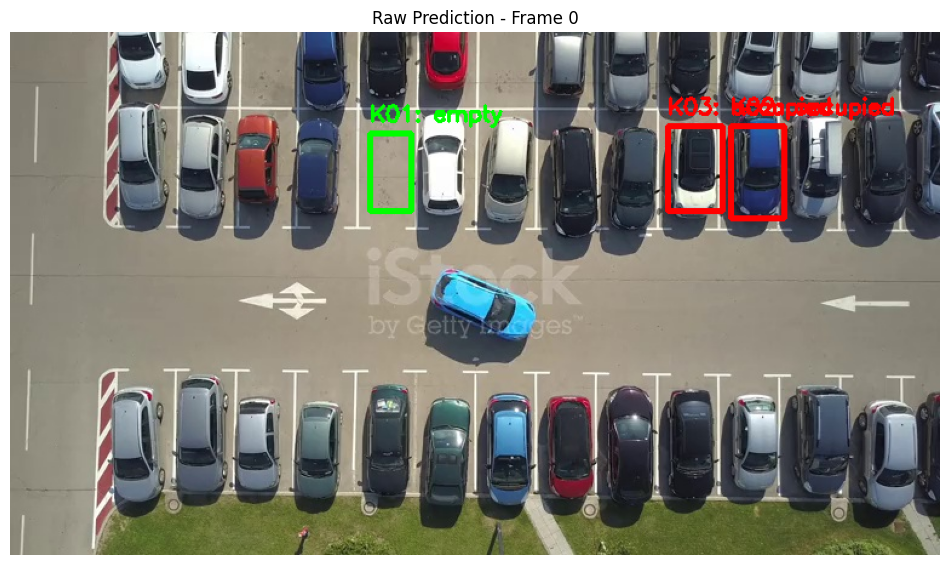

In [25]:
FRAME_ID = 0
FRAME_PATH = f'../data/raw_frames/frame_{FRAME_ID:04d}.jpg'

if os.path.exists(FRAME_PATH):
    frame = cv2.imread(FRAME_PATH)
    vis_frame = frame.copy()
    
    for spot in parking_spots:
        x, y, w, h = spot['box']
        roi = frame[y:y+h, x:x+w]
        # Gọi trực tiếp analyze_spot để lấy kết quả chưa lọc
        status = pipeline.analyze_spot(roi)
        
        color = (0, 255, 0) if status == 'empty' else (0, 0, 255)
        cv2.rectangle(vis_frame, (x, y), (x + w, y + h), color, 3)
        cv2.putText(vis_frame, f"{spot['id']}: {status}", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
    plt.title(f"Raw Prediction - Frame {FRAME_ID}")
    plt.axis('off')
    plt.show()
else:
    print(f"⚠️ Không tìm thấy {FRAME_PATH}")

### 3. Demo Chuỗi khung hình (Temporal Stability)
Phần này mô phỏng video thực tế: AI cần quan sát vài khung hình để xác nhận trạng thái (Tránh nhấp nháy).

✅ Đã nạp model: ../backend/models/svm_parking_model.xml


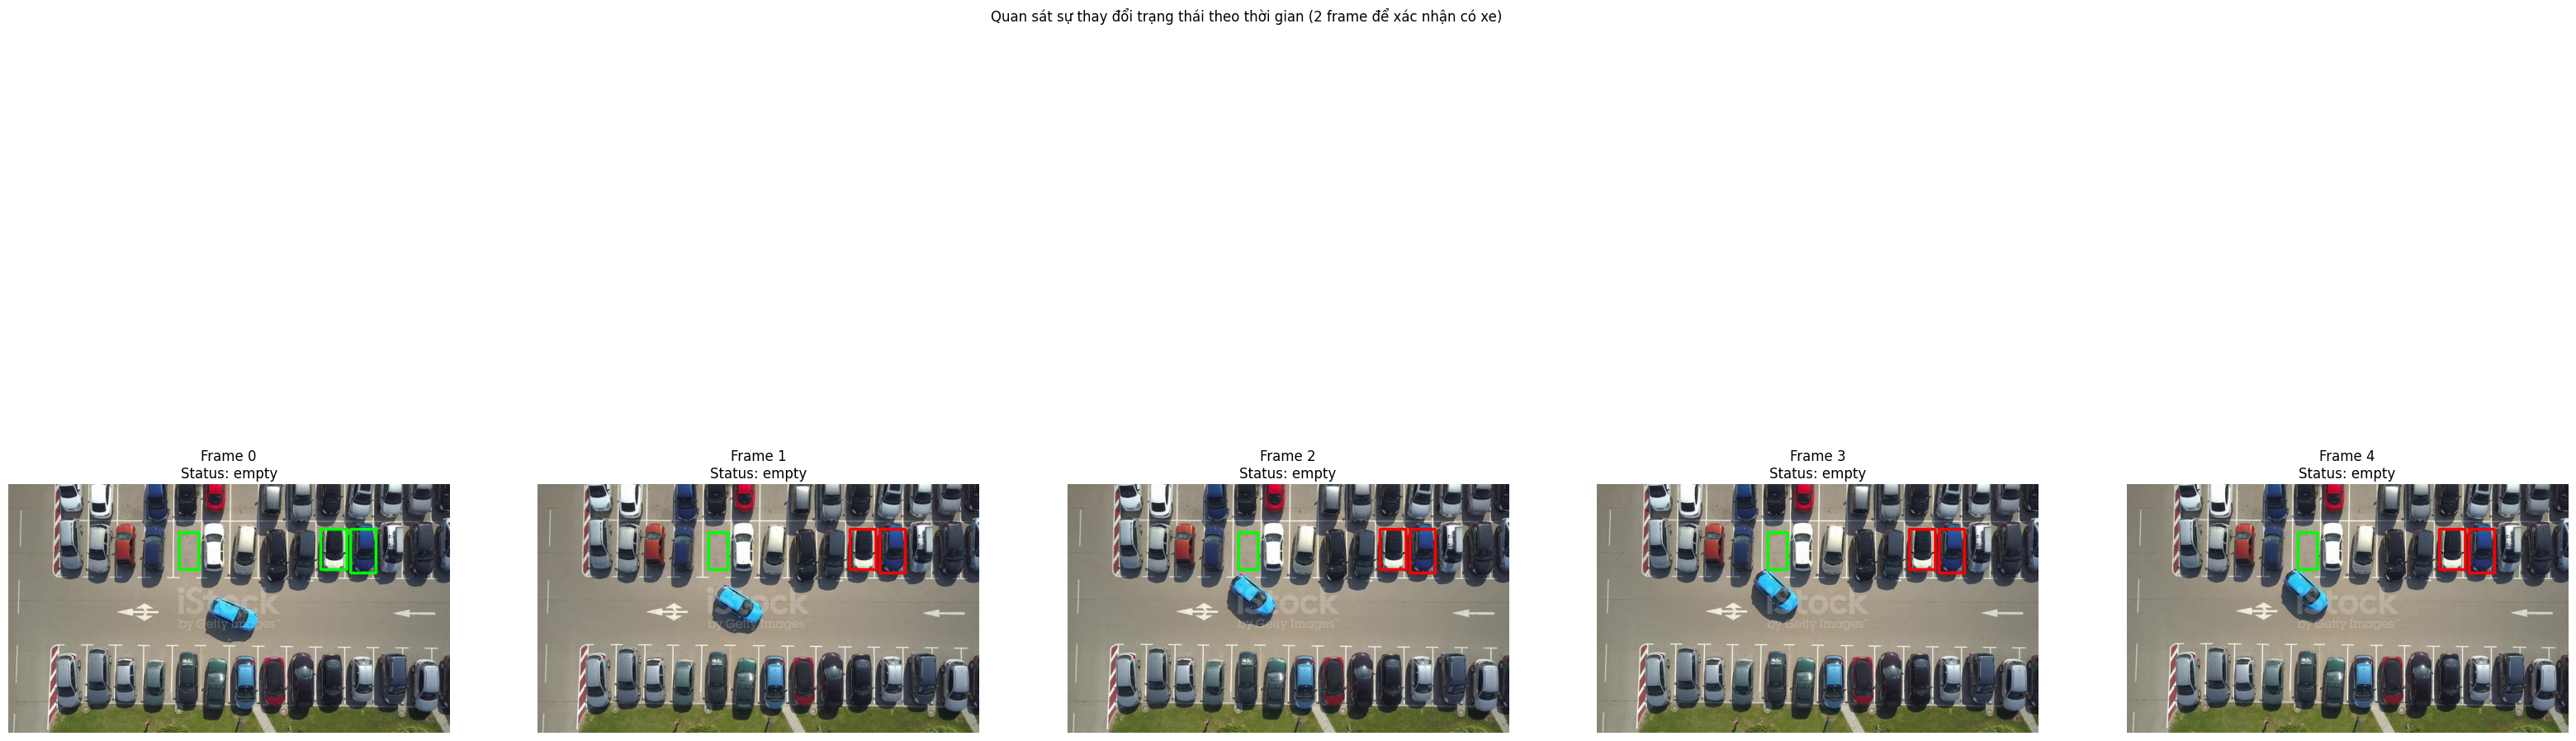

In [26]:
pipeline = ParkingCVPipeline() # Khởi tạo lại để reset history
frames_to_demo = [0, 1, 2, 3, 4]

fig, axes = plt.subplots(1, len(frames_to_demo), figsize=(40, 15))

for i, f_id in enumerate(frames_to_demo):
    frame_path = f'../data/raw_frames/frame_{f_id:04d}.jpg'
    if os.path.exists(frame_path):
        frame = cv2.imread(frame_path)
        # Sử dụng process_frame để kích hoạt logic Smoothing (Chương 5)
        results = pipeline.process_frame(frame, parking_spots)
        
        vis_frame = frame.copy()
        for res in results:
            x, y, w, h = res['box']
            status = res['status']
            color = (0, 255, 0) if status == 'empty' else (0, 0, 255)
            cv2.rectangle(vis_frame, (x, y), (x + w, y + h), color, 3)
        
        axes[i].imshow(cv2.cvtColor(vis_frame, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"Frame {f_id}\nStatus: {results[0]['status']}")
        axes[i].axis('off')

plt.suptitle("Quan sát sự thay đổi trạng thái theo thời gian (2 frame để xác nhận có xe)")
plt.show()

### 4. Phân tích chi tiết (Gỡ lỗi)
Soi kỹ các vùng mẫu bên trong ô đỗ xe.

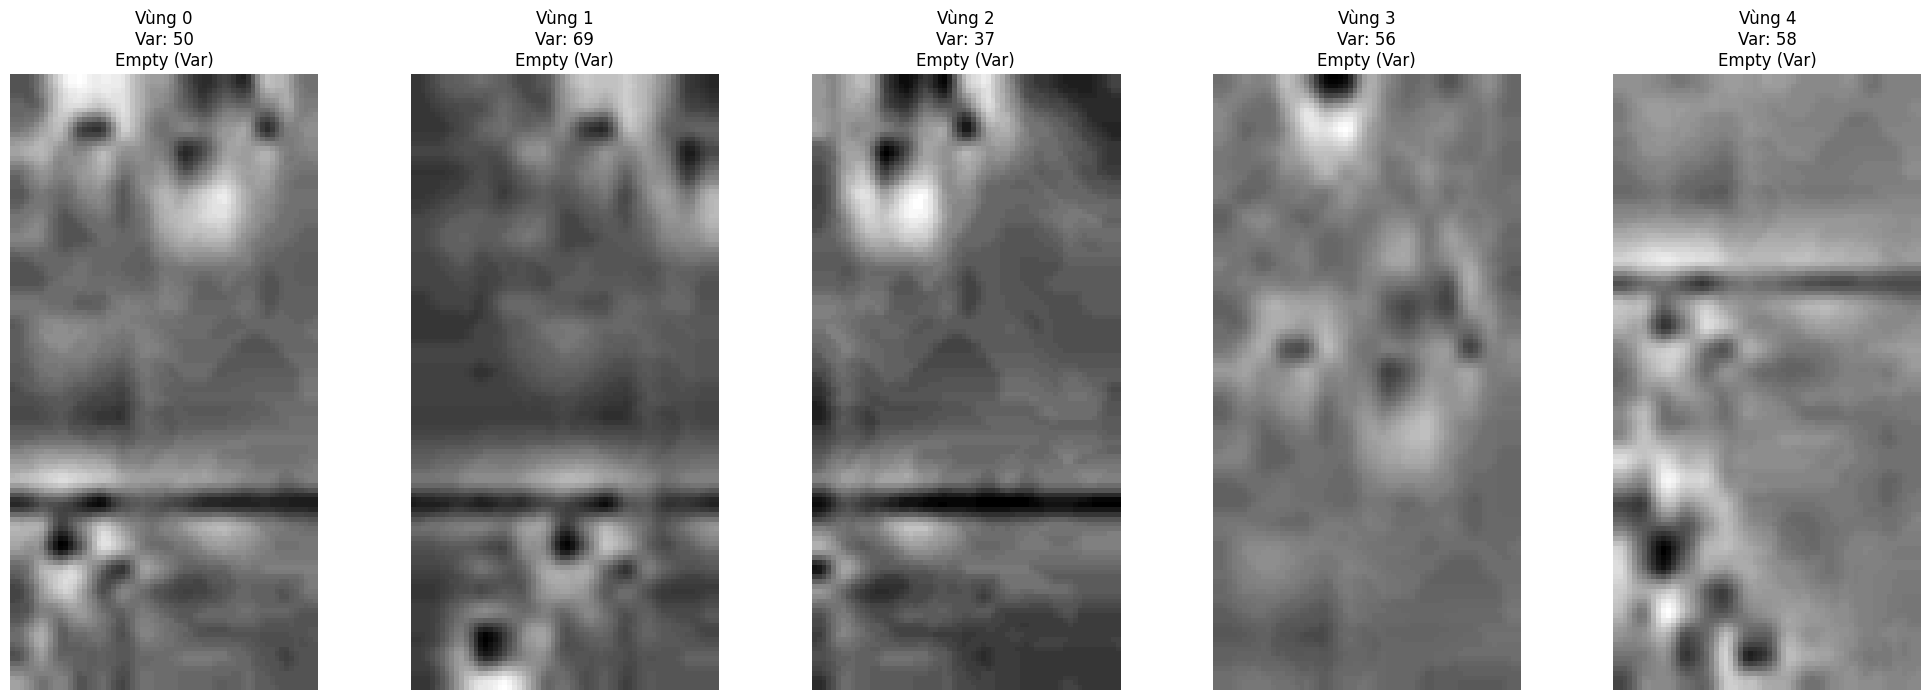

In [27]:
from core_cv.preprocessing import apply_preprocessing
from core_cv.segmentation import is_flat_background

def debug_spot(frame, spot_config, pipeline):
    x, y, w, h = spot_config['box']
    roi = frame[y:y+h, x:x+w]
    regions = pipeline._sample_regions(roi)
    
    plt.figure(figsize=(25, 8))
    for i, region in enumerate(regions):
        pre = apply_preprocessing(region)
        is_empty_bg, var = is_flat_background(pre)
        
        pred = "unknown"
        if is_empty_bg and var < 120:
            pred = "Empty (Var)"
        elif pipeline.svm:
            f = pipeline.hog.compute(pre)
            _, result = pipeline.svm.predict(np.array([f], dtype=np.float32))
            pred = "Occupied (SVM)" if int(result[0][0]) == 1 else "Empty (SVM)"
        
        plt.subplot(1, len(regions), i + 1)
        plt.imshow(pre, cmap='gray')
        plt.title(f"Vùng {i}\nVar: {var:.0f}\n{pred}")
        plt.axis('off')
    plt.show()

if os.path.exists(FRAME_PATH):
    debug_spot(cv2.imread(FRAME_PATH), parking_spots[0], pipeline)